# HEATMAP2 — real study snippet (`SNIPPET_ID = 7`)

This notebook generates **one heatmap per participant** (no longer a single heatmap aggregating
everyone), using the raw data with token/column granularity.

Data sources:

- Fixations (one table per participant × snippet, with real `source_file_col` and `token`):
  `../Merge Fixations/fixations_<participant>/exp_<participant>_db{SNIPPET_ID:02d}_fixation_geral.csv`
- Real source code: `../Code_Snippet/<long_method|data_class|feature_envy>/{SNIPPET_ID}_Code_Snippet.java`
- Metadata (class, method, smell, severity): `../supplementary/code_snippets.xlsx`

**Why per participant:** each file in `Merge Fixations/` is already the real granularity of the
collection — one eye-tracking session per participant per snippet. Mixing everyone into one
heatmap only makes sense as an optional aggregated view; the main view is individual, participant
by participant.

**About the scanpath (`scanpath.png`):** besides the (spatial) heatmap, each participant also has
a "scarf plot" / regression plot — a separate chart, with nothing overlaid on the code, that plots
the **code line on the Y axis** against the **fixation order on the X axis**. This gives a clean
sense of the temporal reading order (used across all three notebooks for consistency), with
regressions (going back to an earlier line) highlighted in red.

**What this notebook produces, organized:**

```text
figures_outputs/snippet{SNIPPET_ID}_{smell_slug}/
├── participant_01/
│   ├── fixation_token_map.csv
│   ├── overlay_diagnostico.png
│   ├── heatmap_final.png
│   ├── heatmap_com_pontos.png
│   └── scanpath.png              (separate chart: line x fixation order, regressions in red)
├── participant_02/
│   └── ...
├── ...
├── all_participants_combined/      (bonus: aggregated view of all participants)
│   └── ...
└── summary_by_participant.csv      (1 row per participant: fixations, dwell time, regressions, etc.)
```

To generate the heatmap for **any other real study snippet**, just change `SNIPPET_ID`
(valid values: 2 to 13) in the configuration cell — the rest of the notebook is generic.

Visual style kept identical to what was originally approved:
- no blue, yellow → orange → red
- low value still visible, more prominent
- diagnostic overlay with transparent bubbles and discreet rectangles

**Note:** participant 3 has fixation data identical to participant 2's (confirmed even in the
original raw `.db3` files, outside this repository) — it is a duplicate caused by a data
collection/export error, not a real reading session. Treat participant 3 as invalid/excluded in
any analysis that assumes independent samples.

In [1]:

from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib import colormaps, font_manager

plt.rcParams["figure.dpi"] = 140


In [2]:
# ============================================================
# HEATMAP CONFIGURATION
# ============================================================

# Real repository data paths (notebook runs from notebooks/).
BASE_DIR = Path("..")
SNIPPETS_XLSX = BASE_DIR / "supplementary" / "code_snippets.xlsx"
# The .java files are organized in subfolders by code smell:
# Code_Snippet/{long_method,data_class,feature_envy,none}/<id>_Code_Snippet.java
CODE_DIR = BASE_DIR / "Code_Snippet"
# Raw per-participant data (with real source_file_col and token).
MERGE_DIR = BASE_DIR / "Merge Fixations"

# Real study snippet (fixation_target). Change here to generate the heatmap
# for any of the 12 analyzed snippets (2 to 13).
SNIPPET_ID = 7

# Participant used in the interactive preview (demo cell). None = use the
# first available participant. Does not affect the batch generation (that
# runs for every participant regardless).
DEMO_PARTICIPANT = None

# Extra context lines before/after the marked method in the file (0 = method only).
CONTEXT_LINES = 0

# Visual parameters of the rendered code.
LEFT_MARGIN = 90
TOP_MARGIN = 20
CHAR_WIDTH = 9.2
TOKEN_HEIGHT = 20
FONT_SIZE = 15
FONT_PATH = font_manager.findfont("DejaVu Sans Mono")

# Avoids letting an absurd duration outlier dominate the heatmap.
MAX_DURATION_FOR_HEATMAP = 5000
MAX_DURATION_FOR_OVERLAY = 5000

# With many participants plotted together (combined heatmap), drawing one
# bubble per individual fixation can saturate the image. Limits how many
# bubbles are drawn per line in the diagnostic/points overlays (does not
# affect the heatmap itself, which uses all fixations).
DISPLAY_SAMPLE_PER_LINE = 40

if not SNIPPETS_XLSX.exists():
    raise FileNotFoundError(f"Snippets spreadsheet not found: {SNIPPETS_XLSX.resolve()}")
if not CODE_DIR.exists():
    raise FileNotFoundError(f"Source code folder not found: {CODE_DIR.resolve()}")
if not MERGE_DIR.exists():
    raise FileNotFoundError(f"'Merge Fixations' folder not found: {MERGE_DIR.resolve()}")

print("SNIPPET_ID:", SNIPPET_ID)

SNIPPET_ID: 7


In [3]:
# ============================================================
# LOCATE THE SNIPPET'S .java FILE AND THE REVIEWED METHOD
# ============================================================
# The real file (e.g. "11_Code_Snippet.java") already contains the markers
# ///* CODE SNIPPET STARTS HERE */// and ///* CODE SNIPPET ENDS HERE *///
# delimiting exactly the method/class that was evaluated in the study.
# This allows detecting LINE_START/LINE_END automatically, without hardcoding.

START_MARKER = "CODE SNIPPET STARTS HERE"
END_MARKER = "CODE SNIPPET ENDS HERE"


def find_snippet_file(snippet_id: int, code_dir: Path) -> Path:
    # Recursive search: the file can be in any code-smell subfolder
    # (long_method / data_class / feature_envy / none).
    matches = sorted(code_dir.rglob(f"{snippet_id}_Code_Snippet*"))
    if not matches:
        raise FileNotFoundError(f"No file found for snippet {snippet_id} in {code_dir}")
    return matches[0]


SNIPPET_FILE = find_snippet_file(SNIPPET_ID, CODE_DIR)
_all_lines = SNIPPET_FILE.read_text(encoding="utf-8", errors="replace").splitlines()
LINE_TEXTS_FULL = {i + 1: line for i, line in enumerate(_all_lines)}

_marker_start = next((ln for ln, txt in LINE_TEXTS_FULL.items() if START_MARKER in txt), None)
_marker_end = next((ln for ln, txt in LINE_TEXTS_FULL.items() if END_MARKER in txt), None)

snippets_meta = pd.read_excel(SNIPPETS_XLSX, sheet_name="code snippets")
meta_rows = snippets_meta.loc[snippets_meta["code_snippet"] == SNIPPET_ID]
meta_row = meta_rows.iloc[0] if not meta_rows.empty else None

if _marker_start is not None and _marker_end is not None:
    LINE_START = _marker_start + 1
    LINE_END = _marker_end - 1
elif meta_row is not None:
    # Fallback: use the lines recorded in the metadata spreadsheet.
    LINE_START = int(meta_row["start_line"])
    LINE_END = int(meta_row["end_line"])
else:
    raise ValueError(f"Could not determine the method lines for snippet {SNIPPET_ID}.")

LINE_START = max(1, LINE_START - CONTEXT_LINES)
LINE_END = min(len(LINE_TEXTS_FULL), LINE_END + CONTEXT_LINES)
LINE_TEXTS = {ln: LINE_TEXTS_FULL[ln] for ln in range(LINE_START, LINE_END + 1)}

TARGET_FILE = SNIPPET_FILE.name
METHOD_NAME = meta_row["code_name"] if meta_row is not None else "(unknown)"
SMELL_TYPE = meta_row["smell"] if meta_row is not None else "(unknown)"
SMELL_SEVERITY = meta_row["severity"] if meta_row is not None else "(unknown)"

# Output folder organized by snippet + smell type -> per participant.
SMELL_SLUG = re.sub(r"[^a-z0-9]+", "_", str(SMELL_TYPE).strip().lower()).strip("_") or "unknown"
OUTPUT_DIR = BASE_DIR / "figures_outputs" / f"snippet{SNIPPET_ID}_{SMELL_SLUG}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Folder (code smell):", SNIPPET_FILE.parent.name)
print("File:", TARGET_FILE)
print("Method/class:", METHOD_NAME)
print("Smell:", SMELL_TYPE, "-", SMELL_SEVERITY)
print("Method lines:", LINE_START, "-", LINE_END, f"({len(LINE_TEXTS)} lines)")
print("Output organized in:", OUTPUT_DIR.resolve())

Folder (code smell): data_class
File: 7_Code_Snippet.java
Method/class: org.eclipse.texlipse.builder.XelatexRunner
Smell: data class - critical
Method lines: 21 - 55 (35 lines)
Output organized in: /home/marioless/Documents/EoS-tosem2026/figures_outputs/snippet7_data_class


Generated image size: 654 x 740


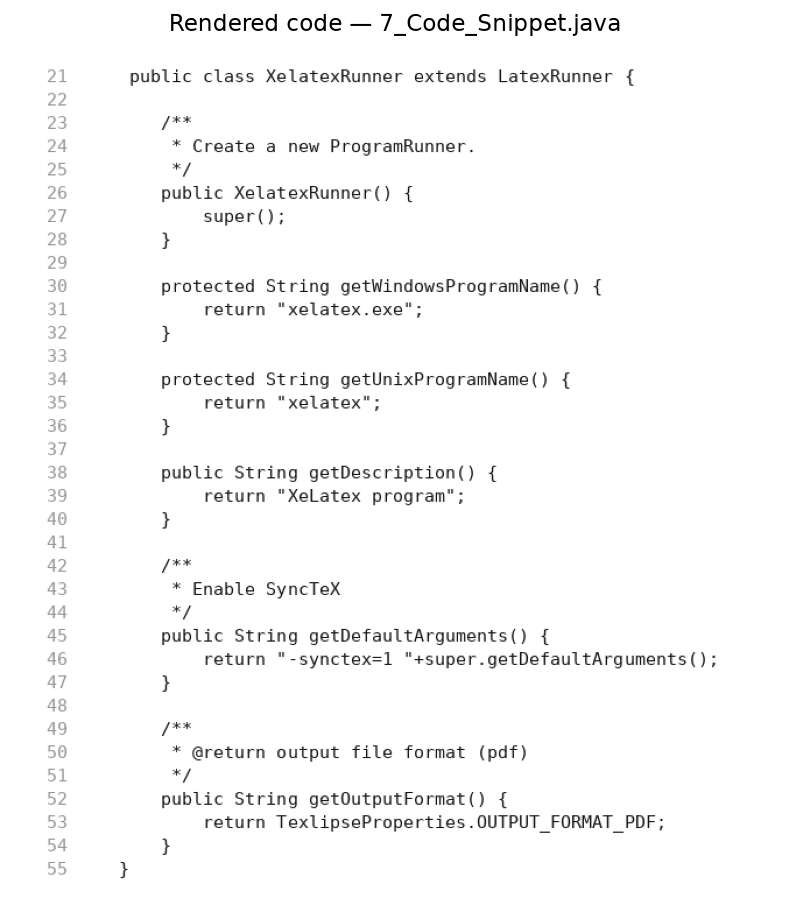

In [4]:
# ============================================================
# RENDER THE CODE AS A BACKGROUND IMAGE (shared by all participants)
# ============================================================
# There is no screenshot of the snippet in the repository, so the
# background image is drawn from the real .java text (monospace font +
# line numbers), preserving the layout used by the rest of the notebook
# (LEFT_MARGIN / CHAR_WIDTH / TOKEN_HEIGHT).

def render_code_image(line_texts: dict, line_start: int, line_end: int) -> Image.Image:
    font = ImageFont.truetype(str(FONT_PATH), FONT_SIZE)
    n_lines = line_end - line_start + 1
    max_chars = max((len(t) for t in line_texts.values()), default=1)
    img_w = int(LEFT_MARGIN + max_chars * CHAR_WIDTH + 40)
    img_h = int(TOP_MARGIN * 2 + n_lines * TOKEN_HEIGHT)
    img = Image.new("RGBA", (img_w, img_h), (255, 255, 255, 255))
    draw = ImageDraw.Draw(img)
    for i, line_no in enumerate(range(line_start, line_end + 1)):
        y = TOP_MARGIN + i * TOKEN_HEIGHT
        draw.text((10, y), f"{line_no:>4}", font=font, fill=(150, 150, 150, 255))
        draw.text((LEFT_MARGIN, y), line_texts.get(line_no, ""), font=font, fill=(20, 20, 20, 255))
    return img


base_img = render_code_image(LINE_TEXTS, LINE_START, LINE_END)
IMG_W, IMG_H = base_img.size
print("Generated image size:", IMG_W, "x", IMG_H)

plt.figure(figsize=(14, 8))
plt.imshow(base_img)
plt.axis("off")
plt.title(f"Rendered code — {TARGET_FILE}")
plt.show()

In [5]:
# ============================================================
# DISCOVER EACH PARTICIPANT'S FIXATION FILE FOR THIS SNIPPET
# ============================================================

def list_participant_files(snippet_id: int, merge_dir: Path):
    pattern = f"fixations_*/exp_*_db{snippet_id:02d}_fixation_geral.csv"
    files = sorted(merge_dir.glob(pattern))
    result = []
    for f in files:
        participant_id = int(f.parent.name.replace("fixations_", ""))
        result.append((participant_id, f))
    return sorted(result)


PARTICIPANT_FILES = list_participant_files(SNIPPET_ID, MERGE_DIR)

if not PARTICIPANT_FILES:
    raise FileNotFoundError(f"No participant file found in {MERGE_DIR} for snippet {SNIPPET_ID}.")

print(f"{len(PARTICIPANT_FILES)} participants with data for snippet {SNIPPET_ID}:")
print([pid for pid, _ in PARTICIPANT_FILES])

26 participants with data for snippet 7:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 27]


In [6]:
# ============================================================
# FUNCTIONS: LOAD ONE PARTICIPANT AND MAP TOKEN → POSITION IN THE IMAGE
# ============================================================
# source_file_col and token are real in this dataset, so each fixation is
# positioned at the exact character/token within the line — no jitter, no
# approximation. The token -> character position matching logic is the
# same as the original heatmap drawing (find_all_spans / map_token_occurrences).


def normalize_token(token: str) -> str:
    token = str(token)
    replacements = {
        "&lt;": "<", "&gt;": ">", "&amp;": "&",
        "lt;": "<", "gt;": ">", "amp;": "&",
    }
    for old, new in replacements.items():
        token = token.replace(old, new)
    return token


def find_all_spans(line_text: str, token: str):
    if not line_text or not token:
        return []

    candidates_to_try = [str(token), normalize_token(token)]
    stripped = normalize_token(token).strip().strip(";,:()[]{}")
    if stripped:
        candidates_to_try.append(stripped)

    seen_queries = set()
    for query in candidates_to_try:
        if not query or query in seen_queries:
            continue
        seen_queries.add(query)
        pattern = re.escape(query)
        spans = [(m.start(), m.end(), "matched") for m in re.finditer(pattern, line_text, flags=re.IGNORECASE)]
        if spans:
            return spans
    return []


def map_token_occurrences(df_line_token: pd.DataFrame, line_text: str):
    token = str(df_line_token["token"].iloc[0])
    candidates = find_all_spans(line_text, token)
    unique_cols = sorted(df_line_token["source_file_col"].dropna().astype(int).unique().tolist())

    col_to_span = {}

    if token == "WHITESPACE":
        max_col = max(unique_cols) if unique_cols else 1
        for col in unique_cols:
            frac = min(max(col / max(max_col, 1), 0), 1)
            start = int(round(frac * max(len(line_text) - 1, 1)))
            col_to_span[col] = (start, min(start + 1, len(line_text)), "approx_whitespace")
        return col_to_span

    if not candidates:
        for col in unique_cols:
            mid = max(len(line_text) // 2, 0)
            col_to_span[col] = (mid, min(mid + max(len(token), 1), len(line_text)), "unresolved")
        return col_to_span

    candidates = sorted(candidates, key=lambda t: t[0])
    if len(candidates) >= len(unique_cols):
        for i, col in enumerate(unique_cols):
            col_to_span[col] = candidates[min(i, len(candidates) - 1)]
    else:
        for i, col in enumerate(unique_cols):
            idx = round(i * (len(candidates) - 1) / max(len(unique_cols) - 1, 1))
            col_to_span[col] = candidates[idx]

    return col_to_span


def line_y(line_no: int):
    idx = line_no - LINE_START
    return TOP_MARGIN + idx * TOKEN_HEIGHT


def span_to_bbox(line_no: int, start_idx: int, end_idx: int):
    x1 = LEFT_MARGIN + start_idx * CHAR_WIDTH
    x2 = LEFT_MARGIN + max(end_idx, start_idx + 1) * CHAR_WIDTH
    y1 = line_y(line_no)
    y2 = y1 + TOKEN_HEIGHT
    return x1, y1, x2, y2


MAPPED_COLUMNS = [
    "fixation_id", "experiment", "fixation_order_number", "duration", "duration_clipped",
    "source_file_line", "source_file_col", "token", "line_text", "match_type",
    "bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2", "center_x", "center_y",
]


def load_fixations_for_participant(path: Path, participant_id: int) -> pd.DataFrame:
    part_df = pd.read_csv(path, sep="\t")
    part_df["experiment"] = participant_id
    fix = part_df[part_df["source_file_line"].between(LINE_START, LINE_END)].copy()
    return fix.sort_values(["source_file_line", "token", "source_file_col", "fixation_order_number"])


def map_fixations(fix: pd.DataFrame) -> pd.DataFrame:
    if fix.empty:
        return pd.DataFrame(columns=MAPPED_COLUMNS)

    mapped_rows = []
    for line_no, df_line in fix.groupby("source_file_line"):
        line_no = int(line_no)
        line_text = LINE_TEXTS.get(line_no, "")

        for token, df_lt in df_line.groupby("token"):
            col_map = map_token_occurrences(df_lt, line_text)

            for _, r in df_lt.iterrows():
                col = int(r["source_file_col"]) if not pd.isna(r["source_file_col"]) else None
                start_idx, end_idx, match_type = col_map.get(col, (0, 1, "missing_col_map"))
                x1, y1, x2, y2 = span_to_bbox(line_no, start_idx, end_idx)
                dur = float(r["duration"])

                mapped_rows.append({
                    "fixation_id": r["fixation_id"],
                    "experiment": r["experiment"],
                    "fixation_order_number": r["fixation_order_number"],
                    "duration": dur,
                    "duration_clipped": min(dur, MAX_DURATION_FOR_HEATMAP),
                    "source_file_line": line_no,
                    "source_file_col": col,
                    "token": str(r["token"]),
                    "line_text": line_text,
                    "match_type": match_type,
                    "bbox_x1": x1, "bbox_y1": y1, "bbox_x2": x2, "bbox_y2": y2,
                    "center_x": (x1 + x2) / 2,
                    "center_y": (y1 + y2) / 2,
                })

    return pd.DataFrame(mapped_rows, columns=MAPPED_COLUMNS).sort_values(["source_file_line", "source_file_col"])

In [7]:
# ============================================================
# FUNCTIONS: BUILD THE IMAGES (OVERLAY, HEATMAP, HEATMAP WITH POINTS, SCANPATH)
# ============================================================
# Same "approved" visual recipe: no blue, yellow -> orange -> red, low
# value still visible. Reusable both for 1 participant and for the
# combined heatmap of everyone.


def sample_for_display(df: pd.DataFrame, per_line: int = DISPLAY_SAMPLE_PER_LINE, seed: int = 7) -> pd.DataFrame:
    if per_line is None or df.empty:
        return df
    return (
        df.groupby("source_file_line", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), per_line), random_state=seed))
    )


def build_overlay_image(mapped: pd.DataFrame) -> Image.Image:
    overlay_layer = Image.new("RGBA", base_img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay_layer, "RGBA")

    for _, r in sample_for_display(mapped).iterrows():
        x1, y1, x2, y2 = r[["bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2"]]
        draw.rectangle([x1, y1, x2, y2], outline=(255, 180, 0, 50), width=1)

        dur_overlay = min(float(r["duration"]), MAX_DURATION_FOR_OVERLAY)
        cx, cy = r["center_x"], r["center_y"]
        radius = max(4, min(18, math.sqrt(dur_overlay) / 2.3))
        draw.ellipse(
            [cx - radius, cy - radius, cx + radius, cy + radius],
            fill=(255, 0, 0, 28),
            outline=(255, 0, 0, 65),
        )

    return Image.alpha_composite(base_img, overlay_layer)


def build_heatmap_image(mapped: pd.DataFrame) -> Image.Image:
    density = np.zeros((IMG_H, IMG_W), dtype=np.float32)

    for _, r in mapped.iterrows():
        cx = float(r["center_x"])
        cy = float(r["center_y"])
        dur = min(float(r["duration"]), MAX_DURATION_FOR_HEATMAP)

        radius = max(4.0, min(18.0, math.sqrt(dur) / 2.3))
        sigma_local = max(4.8, radius * 0.95)
        weight = dur ** 0.92

        pad = int(round(4.0 * sigma_local))
        x0 = max(0, int(cx) - pad)
        x1 = min(IMG_W, int(cx) + pad + 1)
        y0 = max(0, int(cy) - pad)
        y1 = min(IMG_H, int(cy) + pad + 1)

        xx = np.arange(x0, x1) - cx
        yy = np.arange(y0, y1) - cy
        XX, YY = np.meshgrid(xx, yy)

        blob = np.exp(-(XX**2 + YY**2) / (2 * sigma_local**2)) * weight
        density[y0:y1, x0:x1] += blob.astype(np.float32)

    if density.max() > 0:
        density = gaussian_filter(density, sigma=3.4)
        norm = density / density.max()
    else:
        norm = density

    # Final approved parameters: keeps low values visible and avoids a blue background.
    threshold = 0.003
    scaled = np.clip((norm - threshold) / (1 - threshold), 0, 1)
    scaled_gamma = scaled ** 0.58

    cmap = colormaps["YlOrRd"]
    rgba = (cmap(scaled_gamma) * 255).astype(np.uint8)

    alpha = np.zeros_like(scaled_gamma, dtype=np.uint8)
    mask = scaled_gamma > 0
    alpha[mask] = np.clip(75 + scaled_gamma[mask] * 180, 0, 250).astype(np.uint8)
    rgba[..., 3] = alpha

    heat_overlay = Image.fromarray(rgba, mode="RGBA")
    return Image.alpha_composite(base_img, heat_overlay)


def build_points_image(heatmap_result: Image.Image, mapped: pd.DataFrame) -> Image.Image:
    points_layer = Image.new("RGBA", base_img.size, (0, 0, 0, 0))
    points_draw = ImageDraw.Draw(points_layer, "RGBA")

    for _, r in sample_for_display(mapped).iterrows():
        cx, cy = float(r["center_x"]), float(r["center_y"])
        dur_points = min(float(r["duration"]), MAX_DURATION_FOR_OVERLAY)
        radius = max(2, min(9, math.sqrt(dur_points) / 4.2))
        points_draw.ellipse(
            [cx - radius, cy - radius, cx + radius, cy + radius],
            fill=(0, 70, 160, 40),
            outline=(0, 70, 160, 70),
        )

    return Image.alpha_composite(heatmap_result, points_layer)


def build_scanpath_chart(mapped: pd.DataFrame, participant_id: int):
    # "Scarf plot" / regression plot (standard eye-tracking technique in
    # reading research): shows temporal order SEPARATED from the spatial
    # layout, in its own chart, instead of overlaying the path/numbers on
    # the code (which becomes unreadable with many fixations). X axis =
    # fixation order, Y axis = code line. Forward reading rises smoothly;
    # regressions (going back to an earlier line) appear as drops in red.
    ordered = mapped.sort_values("fixation_order_number").reset_index(drop=True)
    order_idx = list(range(1, len(ordered) + 1))
    lines_seq = ordered["source_file_line"].tolist()
    durations = ordered["duration_clipped"].tolist()

    fig, ax = plt.subplots(figsize=(14, 5))

    for i in range(1, len(order_idx)):
        is_regression = lines_seq[i] < lines_seq[i - 1]
        ax.plot(
            [order_idx[i - 1], order_idx[i]],
            [lines_seq[i - 1], lines_seq[i]],
            color="#dc143c" if is_regression else "#4c72b0",
            linewidth=1.8 if is_regression else 1.0,
            alpha=0.9 if is_regression else 0.5,
            zorder=2 if is_regression else 1,
        )

    sizes = [max(10, min(90, d / 12)) for d in durations]
    scatter = ax.scatter(
        order_idx, lines_seq, s=sizes, c=durations, cmap="YlOrRd",
        edgecolors="black", linewidths=0.3, zorder=3, vmin=0,
    )
    fig.colorbar(scatter, ax=ax, label="Fixation duration (ms)", pad=0.01)

    ax.invert_yaxis()
    ax.set_xlabel("Fixation order")
    ax.set_ylabel("Code line")
    ax.set_title(f"Reading sequence (scarf/regression plot) — participant {participant_id:02d}")
    ax.grid(axis="y", alpha=0.25)

    n_regressions = sum(1 for a, b in zip(lines_seq, lines_seq[1:]) if b < a)
    ax.text(
        0.99, 0.03, f"{n_regressions} regressions (red lines)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10, color="#dc143c",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

    fig.tight_layout()
    return fig


def summarize(mapped: pd.DataFrame) -> dict:
    if mapped.empty:
        return {"n_fixations": 0, "dwell_time_ms": 0.0, "top_line": None, "top_token": None, "regressions": 0}

    dwell = float(mapped["duration_clipped"].sum())
    top_line = int(mapped.groupby("source_file_line")["duration_clipped"].sum().idxmax())
    top_line_no, top_token = mapped.groupby(["source_file_line", "token"])["duration_clipped"].sum().idxmax()

    ordered_lines = mapped.sort_values("fixation_order_number")["source_file_line"].tolist()
    regressions = sum(1 for a, b in zip(ordered_lines, ordered_lines[1:]) if b < a)

    return {
        "n_fixations": len(mapped),
        "dwell_time_ms": dwell,
        "top_line": top_line,
        "top_token": f"{top_token} (line {top_line_no})",
        "regressions": regressions,
    }

Participant 01 — 16 fixations, 5436 ms total attention, 5 regressions
Line with most attention: 38
Token with most attention: getDescription (line 38)


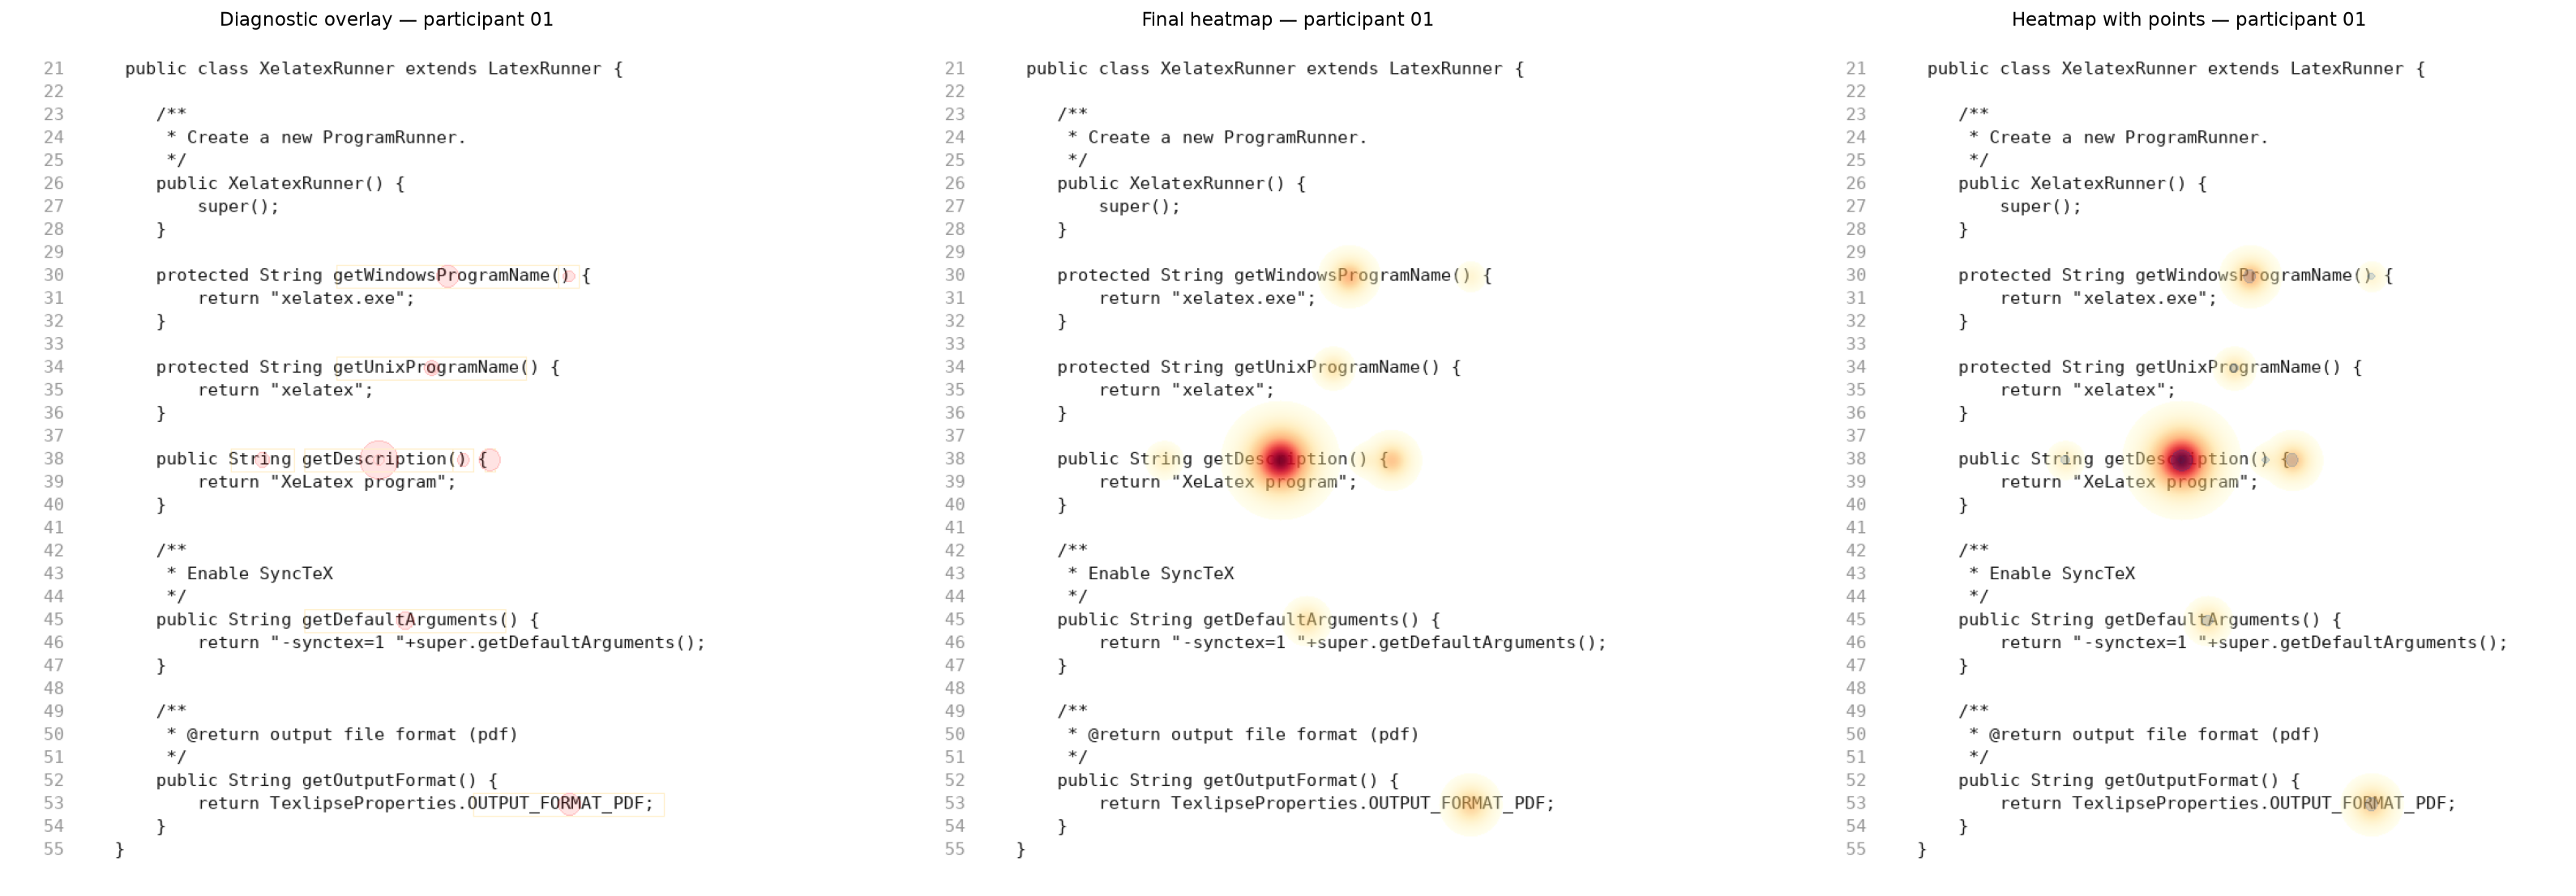

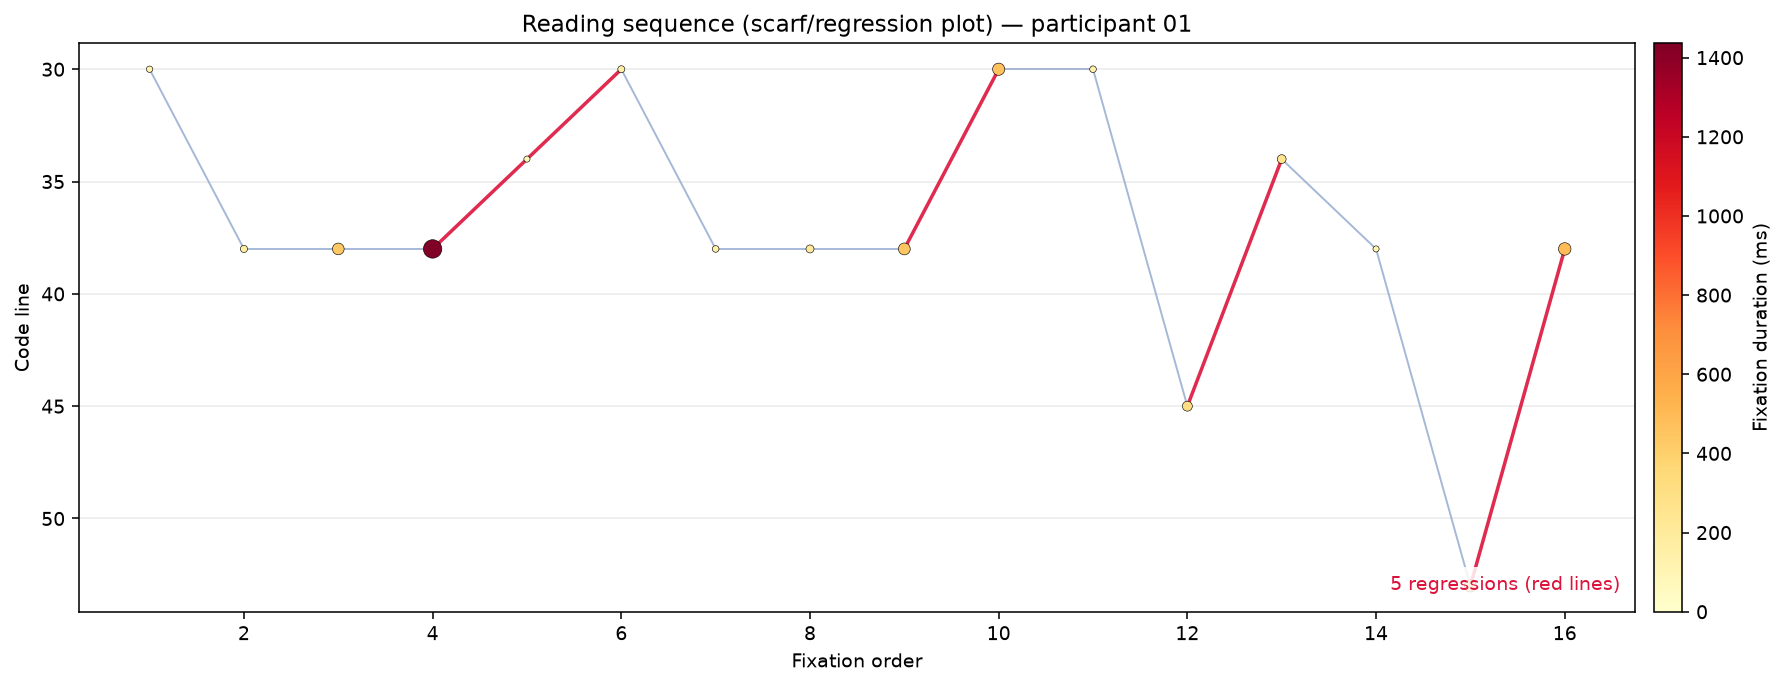

In [8]:
# ============================================================
# INTERACTIVE PREVIEW — 1 PARTICIPANT
# ============================================================
# Quick visualization before generating everything in batch. Change
# DEMO_PARTICIPANT in the configuration to inspect a specific participant.

demo_id = DEMO_PARTICIPANT if DEMO_PARTICIPANT is not None else PARTICIPANT_FILES[0][0]
demo_path = dict(PARTICIPANT_FILES)[demo_id]

fix_demo = load_fixations_for_participant(demo_path, demo_id)
mapped_demo = map_fixations(fix_demo)

if mapped_demo.empty:
    print(f"Participant {demo_id:02d} did not fixate on any token within the method for this snippet.")
else:
    overlay_demo = build_overlay_image(mapped_demo)
    heatmap_demo = build_heatmap_image(mapped_demo)
    points_demo = build_points_image(heatmap_demo, mapped_demo)

    stats_demo = summarize(mapped_demo)
    print(f"Participant {demo_id:02d} — {stats_demo['n_fixations']} fixations, "
          f"{stats_demo['dwell_time_ms']:.0f} ms total attention, {stats_demo['regressions']} regressions")
    print("Line with most attention:", stats_demo["top_line"])
    print("Token with most attention:", stats_demo["top_token"])

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    for ax, img, title in zip(
        axes,
        [overlay_demo, heatmap_demo, points_demo],
        ["Diagnostic overlay", "Final heatmap", "Heatmap with points"],
    ):
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{title} — participant {demo_id:02d}")
    plt.tight_layout()
    plt.show()

    # The scanpath is kept separate (its own chart, not overlaid on the
    # code) -- see the explanation in the notebook's introduction cell.
    scanpath_demo_fig = build_scanpath_chart(mapped_demo, demo_id)
    plt.show()

In [9]:
# ============================================================
# GENERATE FOR ALL PARTICIPANTS (OUTPUT ORGANIZED BY FOLDER)
# ============================================================
# For each participant: maps the fixations, saves the mapping CSV, the 3
# spatial images (overlay, heatmap, heatmap with points) and scanpath.png
# (separate reading-sequence chart) in
# figures_outputs/snippet{SNIPPET_ID}_{smell_slug}/participant_<NN>/, and
# keeps a summary. mapped_frames is reused later for the combined heatmap
# (next cell), without reprocessing everything again.

participant_summaries = []
mapped_frames = []

for participant_id, path in PARTICIPANT_FILES:
    fix_p = load_fixations_for_participant(path, participant_id)
    mapped_p = map_fixations(fix_p)
    mapped_frames.append(mapped_p)

    participant_dir = OUTPUT_DIR / f"participant_{participant_id:02d}"
    participant_dir.mkdir(parents=True, exist_ok=True)
    mapped_p.to_csv(participant_dir / "fixation_token_map.csv", index=False)

    if mapped_p.empty:
        print(f"Participant {participant_id:02d}: no fixations within the method (0 images generated).")
    else:
        overlay_p = build_overlay_image(mapped_p)
        heatmap_p = build_heatmap_image(mapped_p)
        points_p = build_points_image(heatmap_p, mapped_p)
        scanpath_fig = build_scanpath_chart(mapped_p, participant_id)

        overlay_p.save(participant_dir / "overlay_diagnostico.png")
        heatmap_p.save(participant_dir / "heatmap_final.png")
        points_p.save(participant_dir / "heatmap_com_pontos.png")
        scanpath_fig.savefig(participant_dir / "scanpath.png", dpi=140)
        plt.close(scanpath_fig)

    stats_p = summarize(mapped_p)
    stats_p["experiment"] = participant_id
    participant_summaries.append(stats_p)
    print(f"Participant {participant_id:02d}: {stats_p['n_fixations']} fixations, "
          f"{stats_p['dwell_time_ms']:.0f} ms, {stats_p['regressions']} regressions")

summary_by_participant = (
    pd.DataFrame(participant_summaries)[["experiment", "n_fixations", "dwell_time_ms", "regressions", "top_line", "top_token"]]
    .sort_values("dwell_time_ms", ascending=False)
)
summary_by_participant.to_csv(OUTPUT_DIR / "summary_by_participant.csv", index=False)

print()
print(f"Generated for {len(PARTICIPANT_FILES)} participants in: {OUTPUT_DIR.resolve()}")
summary_by_participant

Participant 01: 16 fixations, 5436 ms, 5 regressions


Participant 02: 124 fixations, 51122 ms, 37 regressions


Participant 03: 124 fixations, 51122 ms, 37 regressions


Participant 04: 227 fixations, 73790 ms, 58 regressions


Participant 05: 117 fixations, 56876 ms, 38 regressions


...

Participant 24: 140 fixations, 59903 ms, 51 regressions


Participant 25: 109 fixations, 35994 ms, 30 regressions


Participant 26: 216 fixations, 121686 ms, 51 regressions


Participant 27: 187 fixations, 113780 ms, 56 regressions

Generated for 26 participants in: /home/marioless/Documents/EoS-tosem2026/figures_outputs/snippet7_data_class


,experiment,n_fixations,dwell_time_ms,regressions,top_line,top_token
24,26,216,121686.0,51,53,TexlipseProperties (line 53)
10,11,174,121255.0,52,30,String (line 30)
25,27,187,113780.0,56,30,getWindowsProgramName (line 30)
19,20,132,90453.0,49,46,TexlipseProperties (line 53)
21,23,135,81927.0,42,53,TexlipseProperties (line 53)
8,9,183,77414.0,43,53,TexlipseProperties (line 53)
18,19,118,77226.0,37,52,getOutputFormat (line 52)
15,16,142,75338.0,37,46,XelatexRunner (line 26)
3,4,227,73790.0,58,46,TexlipseProperties (line 53)
13,14,89,70892.0,24,46,getDefaultArguments (line 46)


Combined heatmap (all participants) saved in: /home/marioless/Documents/EoS-tosem2026/figures_outputs/snippet7_data_class/all_participants_combined


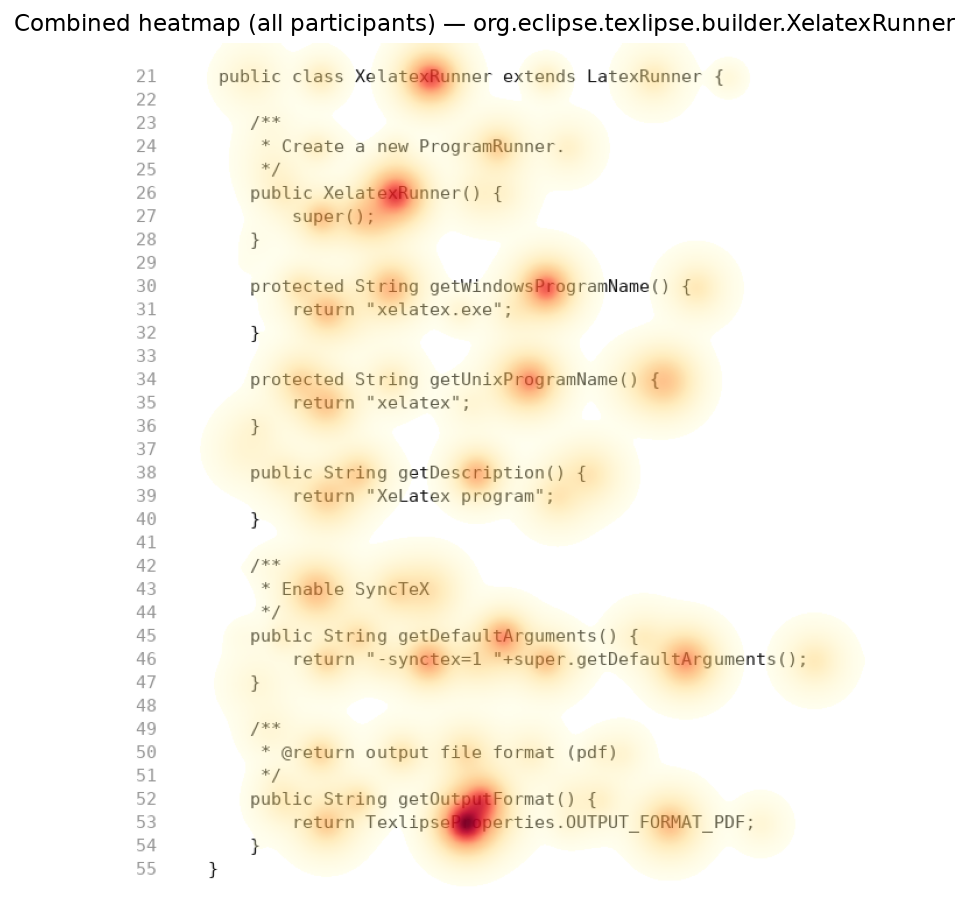

In [10]:
# ============================================================
# BONUS: COMBINED HEATMAP (ALL PARTICIPANTS TOGETHER)
# ============================================================
# Optional aggregated view, useful for comparing against the individual
# heatmaps. Reuses mapped_frames already computed in the previous cell.
# Note: a combined scanpath would mix the temporal order of 26 different
# sessions, so it would not make sense here -- the scanpath that matters
# is the individual, per-participant one.

mapped_all = pd.concat(mapped_frames, ignore_index=True) if mapped_frames else pd.DataFrame(columns=MAPPED_COLUMNS)

combined_dir = OUTPUT_DIR / "all_participants_combined"
combined_dir.mkdir(parents=True, exist_ok=True)
mapped_all.to_csv(combined_dir / "fixation_token_map.csv", index=False)

if mapped_all.empty:
    print("No fixations found for any participant for this snippet/method.")
else:
    overlay_all = build_overlay_image(mapped_all)
    heatmap_all = build_heatmap_image(mapped_all)
    points_all = build_points_image(heatmap_all, mapped_all)

    overlay_all.save(combined_dir / "overlay_diagnostico.png")
    heatmap_all.save(combined_dir / "heatmap_final.png")
    points_all.save(combined_dir / "heatmap_com_pontos.png")

    print("Combined heatmap (all participants) saved in:", combined_dir.resolve())

    plt.figure(figsize=(14, 8))
    plt.imshow(heatmap_all)
    plt.axis("off")
    plt.title(f"Combined heatmap (all participants) — {METHOD_NAME}")
    plt.show()

In [11]:
# ============================================================
# INDEX OF WHAT WAS GENERATED
# ============================================================

generated_dirs = sorted(p for p in OUTPUT_DIR.iterdir() if p.is_dir())

print(f"Snippet {SNIPPET_ID} — {TARGET_FILE} — {METHOD_NAME}")
print(f"Smell: {SMELL_TYPE} ({SMELL_SEVERITY})")
print(f"Output folder: {OUTPUT_DIR.resolve()}")
print(f"{len(generated_dirs)} subfolders generated ({len(PARTICIPANT_FILES)} participants + 1 combined):")
for d in generated_dirs:
    n_files = len(list(d.glob("*")))
    print(f"  - {d.name}/  ({n_files} files)")

print()
print("Summary per participant (also saved in summary_by_participant.csv):")
summary_by_participant

Snippet 7 — 7_Code_Snippet.java — org.eclipse.texlipse.builder.XelatexRunner
Smell: data class (critical)
Output folder: /home/marioless/Documents/EoS-tosem2026/figures_outputs/snippet7_data_class
27 subfolders generated (26 participants + 1 combined):
  - all_participants_combined/  (4 files)
  - participant_01/  (5 files)
  - participant_02/  (5 files)
  - participant_03/  (5 files)
  - participant_04/  (5 files)
  - participant_05/  (5 files)
  - participant_06/  (5 files)
  - participant_07/  (5 files)
  - participant_08/  (5 files)
  - participant_09/  (5 files)
  - participant_10/  (5 files)
  - participant_11/  (5 files)
  - participant_12/  (5 files)
  - participant_13/  (5 files)
  - participant_14/  (5 files)
  - participant_15/  (5 files)
  - participant_16/  (5 files)
  - participant_17/  (5 files)
  - participant_18/  (5 files)
  - participant_19/  (5 files)
  - participant_20/  (5 files)
  - participant_22/  (5 files)
  - participant_23/  (5 files)
  - participant_24/  (5

,experiment,n_fixations,dwell_time_ms,regressions,top_line,top_token
24,26,216,121686.0,51,53,TexlipseProperties (line 53)
10,11,174,121255.0,52,30,String (line 30)
25,27,187,113780.0,56,30,getWindowsProgramName (line 30)
19,20,132,90453.0,49,46,TexlipseProperties (line 53)
21,23,135,81927.0,42,53,TexlipseProperties (line 53)
8,9,183,77414.0,43,53,TexlipseProperties (line 53)
18,19,118,77226.0,37,52,getOutputFormat (line 52)
15,16,142,75338.0,37,46,XelatexRunner (line 26)
3,4,227,73790.0,58,46,TexlipseProperties (line 53)
13,14,89,70892.0,24,46,getDefaultArguments (line 46)
